# Brazilian E-Commerce Analytics

**Dataset:** [Olist Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — ~100,000 real orders, 2016–2018  
**Stack:** Python · SQLite · Pandas · NumPy · Matplotlib · SciPy · GeoPandas  
**Repo:** [github.com/avi2898/Brazilian-eCommerce-Data-Project](https://github.com/avi2898/Brazilian-eCommerce-Data-Project)

> **About this notebook:** This is a **presentation-layer walkthrough** of the project.
> The full implementation lives in `src/`. Charts are pre-embedded and render without running any code.
> See [How to Run Locally](#how-to-run-locally) at the bottom to reproduce results on your machine.

---
## Research Questions

| # | Research Question | Core Method |
|---|---|---|
| 1 | **Logistics Efficiency** — Which Brazilian regions over- or underperform delivery expectations relative to distance? | Log-linear OLS regression · residual analysis · geospatial scatter plot |
| 2 | **Sales Trends & Seasonality** — What is the pattern of monthly revenue growth, and where are the seasonal peaks? | SQL window functions (`LAG`, `SUM OVER`) · dual-axis combo chart |
| 3 | **Seller Revenue Outlook** — What can a new seller realistically expect to earn per month, and how uncertain is that? | Nonparametric bootstrap simulation (10,000 draws) |
| 4 | **Payment Methods: Risk vs Value** — Do payment methods differ in cancellation risk and average order value? | Risk–value bubble chart (AOV × cancellation rate × volume × revenue) |

---
## Dataset & Business Context

This project uses the public Olist Brazilian e-commerce dataset, an anonymized multi-table dataset covering roughly 100,000 orders placed between 2016 and 2018 across Brazilian marketplaces. It links orders, customers, sellers, payments, reviews, product attributes, and geolocation, making it suitable for analyzing logistics performance, sales trends, seller outcomes, and payment-method behavior. The dataset also includes zip-code-level latitude and longitude data, which supports spatial analysis of delivery efficiency and regional bottlenecks.

Operationally, the data captures the order flow from purchase through seller fulfillment, delivery, and post-purchase customer review.

| Category | Details |
|---|---|
| Orders | ~100,000 |
| Time period | 2016–2018 |
| Tables | 9 relational tables |
| Geography | Zip-code-level geolocation |
| Payments | Credit card, boleto, voucher, debit card |
| Reviews | Customer review scores and text |

Raw CSV files are not committed to this repository due to file size (122 MB+ combined).
Download from [Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) and place in `data/` before running.

---
## Project Architecture

```
project_root/
├── main.py                  ← CLI entry point — runs any or all questions
├── requirements.txt         ← pinned dependencies
├── project_walkthrough.ipynb ← this notebook
│
├── src/
│   ├── __init__.py          ← marks src/ as a Python package
│   ├── db_setup.py          ← loads CSVs into SQLite; exposes query() helper
│   ├── question1.py         ← Q1: logistics efficiency & residual analysis
│   ├── question2.py         ← Q2: sales trends & seasonality
│   ├── question3.py         ← Q3: seller revenue bootstrap simulation
│   └── question4.py         ← Q4: payment methods risk–value analysis
│
├── outputs/
│   ├── question_1/          ← charts saved by question1.py
│   ├── question_2/
│   ├── question_3/
│   └── question_4/
│
├── data/                    ← raw CSVs (git-ignored; download from Kaggle)
├── ecommerce.db             ← SQLite database (git-ignored; built from CSVs)
│
└── docs/
    └── codebase_guide.md    ← architecture and code walkthrough
```

**Key design principles:**

| Principle | Implementation |
|---|---|
| Single shared database | All question modules call the same `query()` helper; no CSV reads after setup |
| Separation of concerns | Each question file owns its data loading, computation, and chart output |
| Self-contained outputs | Charts save to `outputs/question_N/` with no shared state between modules |
| CLI extensibility | `main.py` uses `importlib.import_module()` — adding Q5 needs one new file and one new line |

---
## Tools & Libraries

| Library | Version | Role in this project |
|---|---|---|
| Python | 3.10+ | Core language |
| SQLite + `sqlite3` | stdlib | Local relational database — no server required |
| Pandas | ≥ 2.0 | SQL result handling, data manipulation, time-series filtering |
| NumPy | ≥ 1.24 | Vectorised distance calculation, bootstrap sampling, statistics |
| Matplotlib | ≥ 3.7 | All four output charts (dual-axis, scatter, histogram, bubble) |
| SciPy | ≥ 1.11 | Pearson correlation for regression fit and residual diagnostics (Q1) |
| GeoPandas | ≥ 0.14 | Natural Earth shapefile for Brazil map background (Q1) |

---
## Database Setup

### Why SQLite?

The Olist data comes as 9 separate CSV files. Rather than re-reading all 9 files on every run,
the project loads them once into a local **SQLite database** (`ecommerce.db`).
This gives several practical benefits:

- **Speed** — queries hit an indexed binary file, not raw CSVs
- **SQL** — joins, aggregations, and window functions can be written directly in SQL rather than Python
- **Zero infrastructure** — SQLite is a single file, built into Python's standard library, requires no server
- **Reproducibility** — the database is rebuilt from scratch with one command; no manual data wrangling

### What `src/db_setup.py` does

1. Defines a `TABLES` registry mapping each SQLite table name to its source CSV filename
2. Reads each CSV with `pd.read_csv()`, parsing known date columns automatically
3. Writes each DataFrame to SQLite using `df.to_sql(..., if_exists='replace')` — idempotent, safe to re-run
4. Exposes a `query(sql)` helper that opens a connection, runs any SQL statement, and returns a DataFrame

### Step-by-step workflow

```
Step 1 — Download CSVs from Kaggle
         https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

Step 2 — Place all CSV files in the data/ folder
         data/olist_orders_dataset.csv
         data/olist_customers_dataset.csv
         data/olist_order_items_dataset.csv
         ... (9 files total)

Step 3 — Build the database (one-time setup)
         python -m src.db_setup
         → Reads all 9 CSVs
         → Creates ecommerce.db at project root
         → Prints row counts per table as a sanity check

Step 4 — Run the analysis
         python main.py              # all four questions
         python main.py --question 2 # single question
```

After Step 3, the CSV files are no longer read. Every question module queries `ecommerce.db` directly.

In [ ]:
# Code excerpt from src/db_setup.py

# Registry: SQLite table name → source CSV filename
TABLES = {
    "orders":               "olist_orders_dataset.csv",
    "customers":            "olist_customers_dataset.csv",
    "order_items":          "olist_order_items_dataset.csv",
    "order_payments":       "olist_order_payments_dataset.csv",
    "order_reviews":        "olist_order_reviews_dataset.csv",
    "products":             "olist_products_dataset.csv",
    "sellers":              "olist_sellers_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
    "geolocation":          "olist_geolocation_dataset.csv",
}

# The query() helper — used by every question module
def query(sql: str) -> pd.DataFrame:
    with sqlite3.connect('ecommerce.db') as conn:
        return pd.read_sql_query(sql, conn)

# Example call from question2.py
df = query("SELECT * FROM orders WHERE order_status = 'delivered' LIMIT 5")

---
## Database Schema

Nine tables are loaded from CSV into SQLite. The relational structure is built around `order_id`, `customer_id`, `seller_id`, and zip-code prefix.

| Table | Rows | Primary Key | Foreign Keys | Key columns |
|---|---|---|---|---|
| `orders` | 99,441 | `order_id` | `customer_id` → customers | `order_status`, `order_purchase_timestamp`, `order_delivered_customer_date` |
| `order_items` | 112,650 | *(composite)* | `order_id` → orders · `seller_id` → sellers · `product_id` → products | `price`, `freight_value` |
| `order_payments` | 103,886 | — | `order_id` → orders | `payment_type`, `payment_value` |
| `order_reviews` | 99,224 | — | `order_id` → orders | `review_score`, `review_creation_date` |
| `customers` | 99,441 | `customer_id` | zip prefix → geolocation | `customer_state`, `customer_zip_code_prefix` |
| `sellers` | 3,095 | `seller_id` | zip prefix → geolocation | `seller_zip_code_prefix`, `seller_state` |
| `products` | 32,951 | `product_id` | — | `product_category_name` |
| `geolocation` | 1,000,163 | *(zip prefix)* | — | `geolocation_lat`, `geolocation_lng` |
| `category_translation` | 71 | `product_category_name` | — | `product_category_name_english` |

**Key relationships:**
- `orders` ↔ `order_items` via `order_id` (one order, many items)
- `order_items` ↔ `sellers` via `seller_id`
- `order_items` ↔ `products` via `product_id`
- `orders` ↔ `customers` via `customer_id`
- `orders` ↔ `order_payments` via `order_id`
- `orders` ↔ `order_reviews` via `order_id`
- `customers` / `sellers` ↔ `geolocation` via zip-code prefix

> **Q1 distance join:** `customers` and `sellers` are both resolved to lat/lng via `geolocation` on zip-code prefix. The Haversine formula is then applied to each seller–customer coordinate pair to compute great-circle delivery distance in km.

---
## How the Project Runs

`main.py` is the single entry point. It uses `importlib.import_module()` to load question modules
dynamically at runtime — meaning adding a new question requires only one new file and one new line in `main.py`.

```
python main.py --question 2
       │
       ▼
  main.py::main()
  ├── creates outputs/question_2/ if needed
  └── importlib.import_module('src.question2').main()
             │
             ├── load_monthly_sales()  → query(sql) → pd.DataFrame
             └── build_plot(df)        → saves PNG to outputs/question_2/
```

Each question module follows the same pattern:
1. Load data from SQLite via `query(sql)`
2. Run analysis in Python (regression / simulation / aggregation)
3. Build chart and save to `outputs/question_N/`

```bash
python main.py               # runs all four questions in sequence
python main.py --question 1  # runs only Q1
python -m src.question3      # runs Q3 directly
```

---
## Question 1 — Logistics Efficiency & Residual Analysis

**Business question:** How efficiently does the logistics network convert delivery distance into actual delivery time, and which Brazilian regions over- or underperform relative to what distance alone would predict?

**Why a residual-based approach?**

`order_estimated_delivery_date` is available in the dataset but excluded from this analysis. Estimated delivery dates appear to incorporate substantial business buffers — in practice, actual delivery often arrives before the promised date, which makes raw delay-versus-estimate a biased and sometimes negative metric. It reflects how conservative the platform’s promises are, not how efficiently the logistics network actually operates.

The analysis instead fits a regression of actual lead time on log(distance) and measures each order’s **residual**: how many days faster or slower than the distance-based prediction. This removes the geographic baseline and isolates what is genuinely controllable — carrier performance, fulfillment centre density, and regional infrastructure.

**Analytical pipeline:**

| Metric / Method | What it measures | Why this choice |
|---|---|---|
| **Actual lead time** | `order_delivered_customer_date − order_purchase_timestamp` in days | Estimated delivery dates are excluded — they contain inflated business buffers that mask true operational speed |
| **Delivery distance** | Haversine great-circle distance between seller and customer zip-code lat/lng | Haversine is geometrically correct for a sphere; Euclidean distance systematically understates it at Brazil’s geographic scale |
| **Log transform** | `log(distance_km + 1)` | Raw distance is heavily right-skewed (most orders under 500 km, some over 3,000 km). Log compresses the tail and models the plausible diminishing marginal effect of each extra km |
| **OLS regression** | `log(distance) → lead_time` via `np.polyfit` | Fits the global expected-performance baseline. The regression line is the answer to: “what lead time would we predict from distance alone?” |
| **Residual** | `actual − predicted` days per order | The core analytical signal. Positive = slower than distance explains (operational friction); negative = faster (efficiency). Residuals isolate carrier and infrastructure performance from geography |
| **Mean Residual (days)** | Average days slower than distance alone predicts, per state | The primary bottleneck signal: isolates operational delay from geography. Paired with total affected orders to distinguish high-severity/low-volume from moderate-severity/high-volume states |

**Chart output — two panels:**

- **Left (map):** Brazil geospatial scatter — each dot is a zip-code prefix, coloured by mean residual (blue = faster than expected, red = bottleneck). Dot size scales with order volume.
- **Right (regression scatter):** Log(distance) vs actual lead time for all 95,977 orders, each coloured by its residual, with OLS trendline. Spread increases at longer distances, indicating greater delivery uncertainty for remote regions.

**Key finding:** Distance explains lead time partially (Pearson r = 0.401, R² = 0.160, n = 95,977). The 84% of variance that distance cannot explain is where the analysis becomes actionable: residual clusters expose genuine operational differences — carrier quality, fulfillment centre density, and infrastructure — that are entirely independent of geography.

**Recommendation:** **SE, CE, PA, and MA** have the highest per-order delays (+3–5 days beyond what distance predicts) and are the strongest targets for regional infrastructure investigation. **RJ** has a lower per-order residual (+1.96 days) but the largest affected volume among bottleneck states (~9,000 orders), making it the highest-priority candidate for a carrier or fulfillment review where any improvement returns at scale. **SP, MG, PR, and DF** consistently undercut predicted lead times and serve as the operational benchmark for underperforming states.

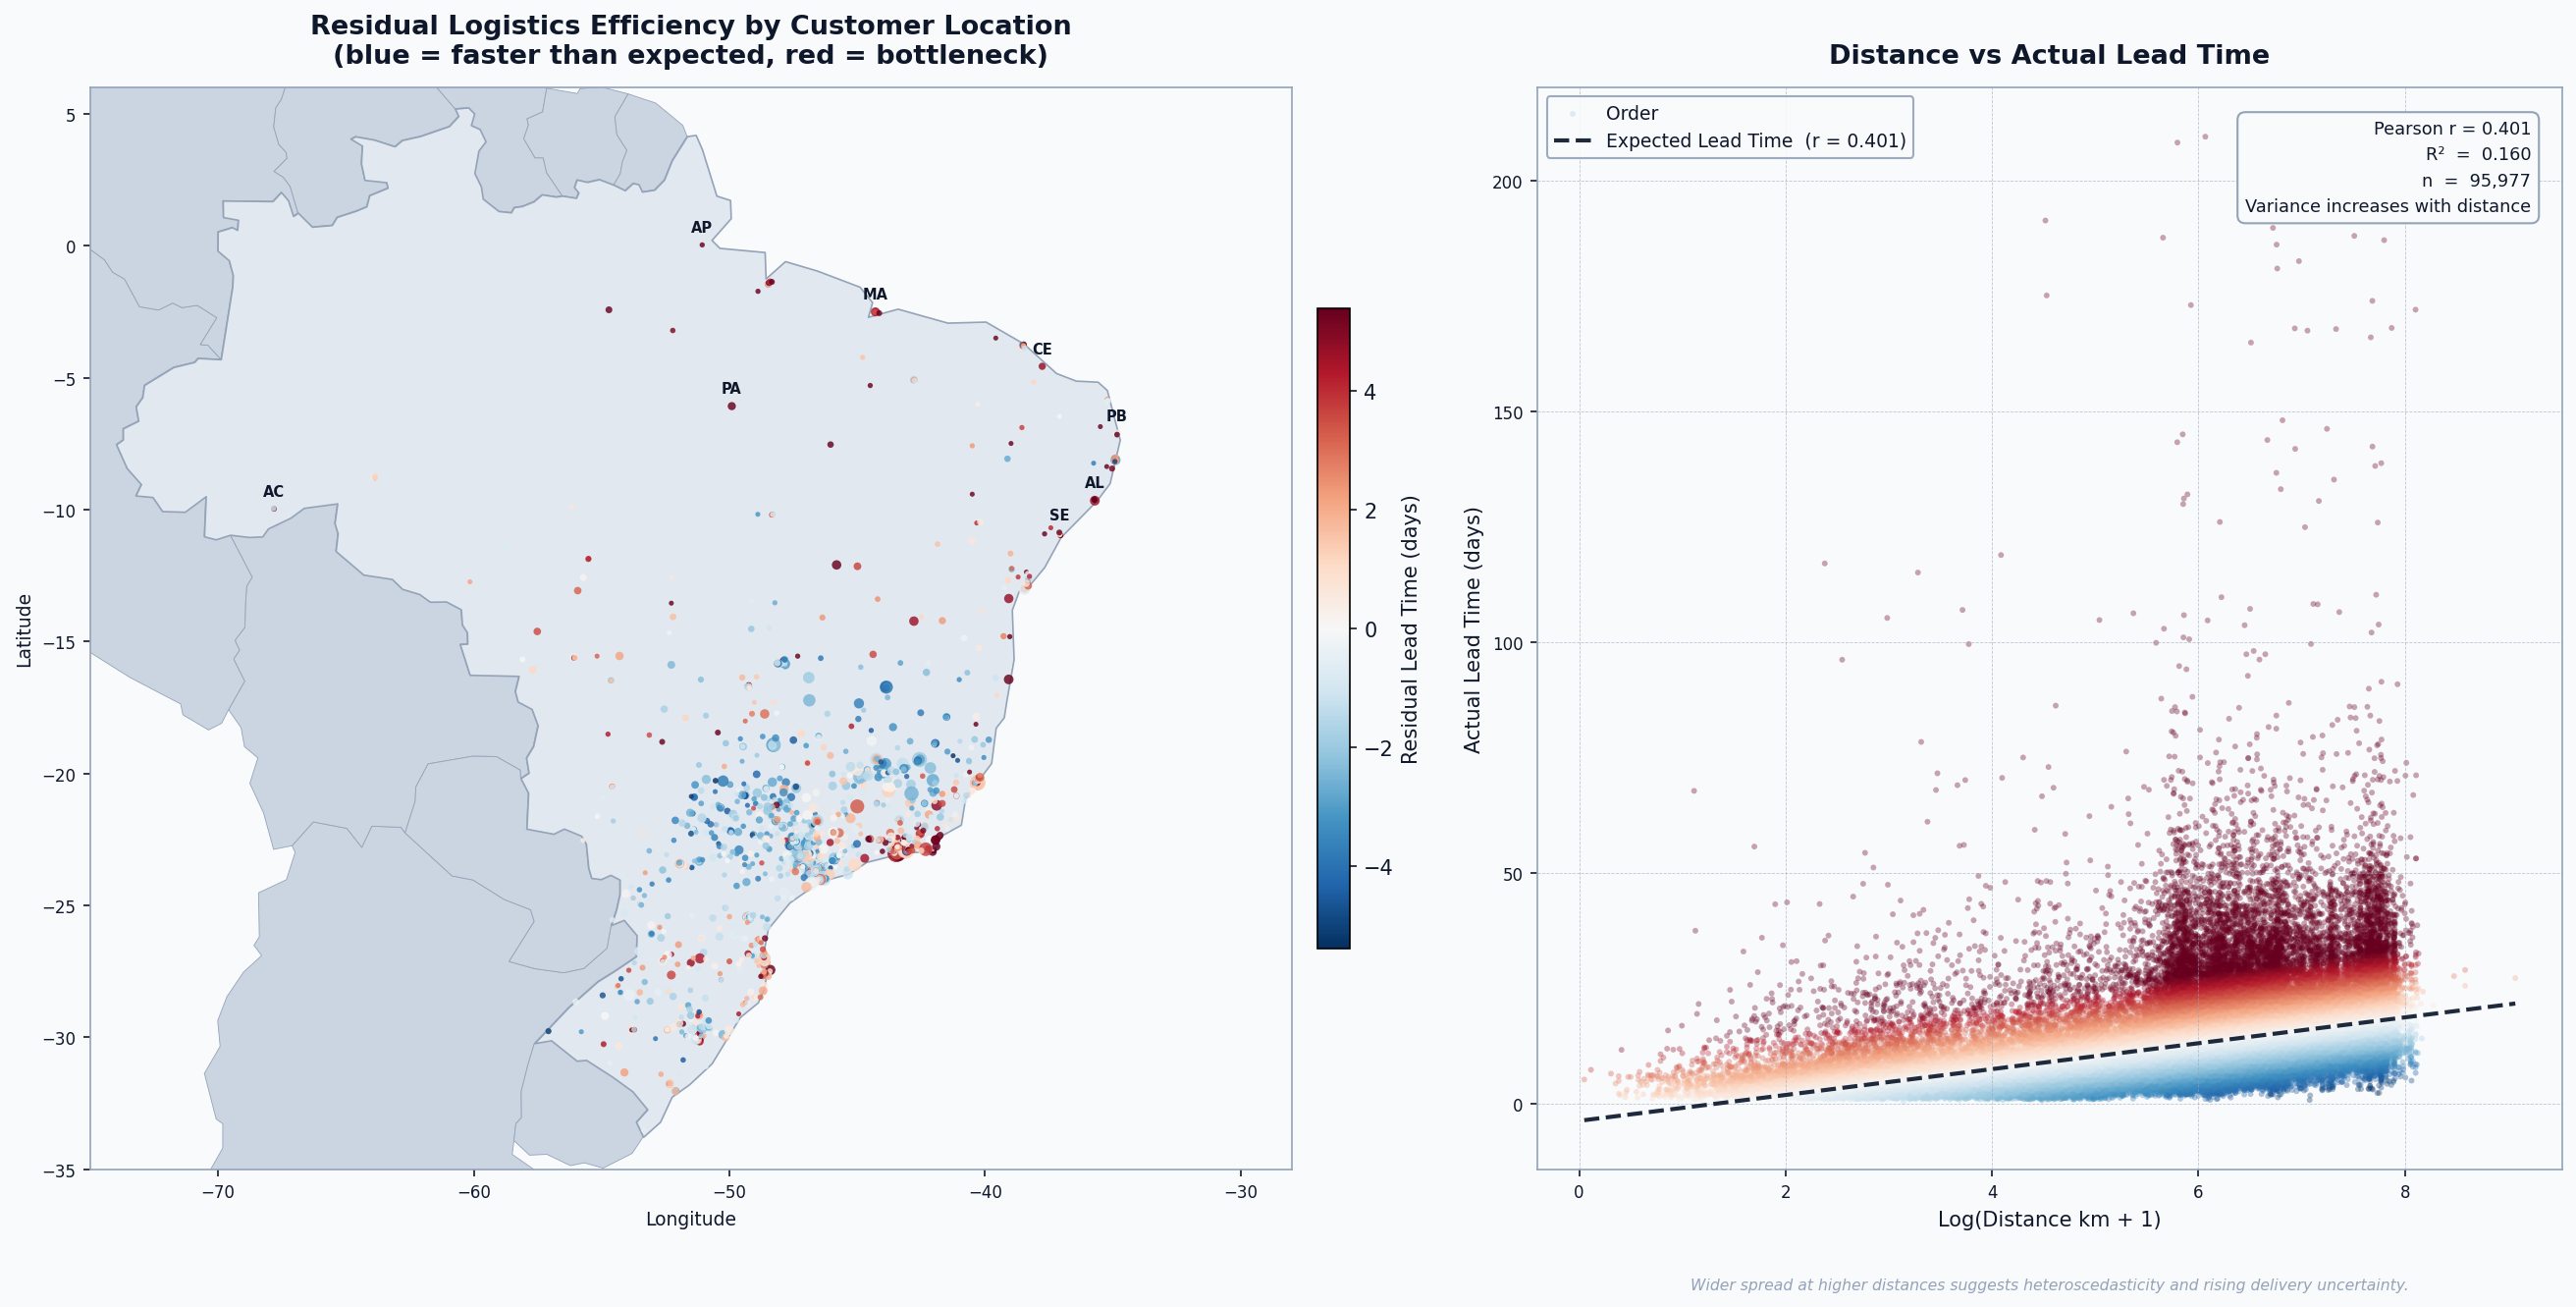

In [1]:
from IPython.display import Image, display
display(Image('outputs/question_1/geographic_delivery_map_and_regression.png', width=1000))

In [1]:
# Bottleneck ranking — computed by run_prioritization(df_geo) in src/question1.py
# States are ranked by mean residual (per-order delay severity)
# Suggested Action is then assigned by a separate rule based on order volume (see cell below)

from src.question1 import (
    load_orders, compute_lead_time, join_customers,
    load_geo, build_regression_dataset, build_geo_dataset, run_prioritization,
)
df = load_orders()
df = compute_lead_time(df)
df = join_customers(df)
geo = load_geo()
df_reg, slope, intercept = build_regression_dataset(df, geo)
df_geo = build_geo_dataset(df_reg, geo)
bottlenecks, efficient = run_prioritization(df_geo)
print("Top 5 bottleneck states")
display(bottlenecks)

Rank,State,Mean Residual (days),Orders,Suggested Action
1,SE,+4.79,121,Regional investigation
2,CE,+3.84,225,Regional investigation
3,MA,+3.58,209,Regional investigation
4,PA,+3.43,325,Regional investigation
5,RJ,+1.96,"9,044",Carrier review


**Reading this table:**

- **Ranking:** states are ordered by **Mean Residual (days)** descending — highest per-order delay first.
- **Mean Residual (days):** how many days slower than distance alone predicts, on average. This is the primary metric: it measures operational delay that geography cannot explain.
- **Total Orders:** how many deliveries are affected. Not used for ranking — used only to determine the Suggested Action.
- **Suggested Action** is a rule-based label assigned after ranking, not the ranking criterion itself:
  - *Carrier review* — positive residual **and** order volume above the national median. Moderate delay affecting many customers — carrier or fulfillment review is worthwhile on scale grounds.
  - *Regional investigation* — positive residual but order volume below the national median. Sharp per-order delay affecting fewer customers — more likely a local infrastructure or last-mile issue.
  - *Monitor* — negative residual (faster than expected). No action needed; useful as a benchmark.

**SE, CE, MA, PA** rank 1–4 by residual severity (+3–5 days per order) — sharpest per-order bottlenecks, lower volume.
**RJ** ranks 5th by residual (+1.96 days) but has ~9,000 affected orders — the only state above the national median order volume, which is why it earns the *Carrier review* label despite a lower per-order delay.

In [1]:
# Most efficient states — consistently deliver faster than distance predicts
# These are the operational benchmarks
print("Most efficient states (operational benchmarks)")
display(efficient)

Rank,State,Mean Residual (days),Orders
1,DF,-1.72,760
2,MG,-1.51,"7,874"
3,PR,-1.39,"2,359"
4,SP,-1.27,"23,674"


**SP, MG, PR, DF** systematically deliver faster than their distances would predict.  
These states serve as **operational benchmarks**: their carrier mix, fulfillment centre
density, and last-mile infrastructure represent the best-practice model for improving underperforming regions.

---
## Question 2 — Sales Trends & Seasonality

**Business question:** What is the pattern of monthly sales growth over time, and which months exhibit seasonal peaks?

**Method:**
- Revenue aggregated monthly as `SUM(price + freight_value)` via SQL JOIN across `orders` and `order_items`
- Analysis restricted to **Jan 2017 – Aug 2018** — the stable, fully-covered data window
- Month-over-month growth computed using SQL window functions in a single query pass
- Dual-axis combo chart: total sales line (left axis) + MoM growth rate bars (right axis)
- Top-3 revenue months annotated directly on the chart

**SQL window function query — from `src/question2.py`:**

In [ ]:
# Excerpt from src/question2.py — window functions computed directly in SQLite
sql = """
WITH monthly AS (
    SELECT strftime('%Y-%m', o.order_purchase_timestamp) AS month,
           SUM(oi.price + oi.freight_value)              AS total_sales,
           COUNT(DISTINCT o.order_id)                    AS total_orders
    FROM orders o JOIN order_items oi USING(order_id)
    WHERE o.order_purchase_timestamp IS NOT NULL
    GROUP BY month
)
SELECT
    month,
    total_sales,
    total_orders,
    -- Previous month sales (LAG) and cumulative total (SUM OVER) are
    -- computed directly in SQL; Python handles type conversion, filtering,
    -- and visualisation downstream
    LAG(total_sales) OVER (ORDER BY month)               AS prev_month_sales,
    -- Month-over-month growth rate
    (total_sales - LAG(total_sales) OVER (ORDER BY month))
        / LAG(total_sales) OVER (ORDER BY month)         AS growth_rate,
    -- Cumulative running total
    SUM(total_sales) OVER (ORDER BY month)               AS cumulative_sales
FROM monthly ORDER BY month
"""
df = query(sql)  # returns a pandas DataFrame ready for plotting

### Monthly sales table from the SQL query

The table below is the direct output of `load_monthly_sales()` in `src/question2.py`. `LAG(total_sales) OVER (ORDER BY month)` computes `prev_month_sales` and the MoM growth rate; `SUM(total_sales) OVER (ORDER BY month)` computes `cumulative_sales` — both in a single SQL pass. Python then handles type conversion, filtering, and visualisation.

In [ ]:
# Full SQL result — all months before filtering
# Source: load_monthly_sales() in src/question2.py
from src.question2 import load_monthly_sales
import pandas as pd
df_raw = load_monthly_sales()
disp = df_raw.copy()
disp['month']            = disp['month'].dt.strftime('%Y-%m')
disp['total_sales']      = disp['total_sales'].apply(lambda v: f'{v:,.0f}')
disp['prev_month_sales'] = disp['prev_month_sales'].apply(lambda v: f'{v:,.0f}' if pd.notna(v) else '—')
disp['cumulative_sales'] = disp['cumulative_sales'].apply(lambda v: f'{v:,.0f}')
disp['total_orders']     = disp['total_orders'].apply(lambda v: f'{v:,}')
disp['growth_rate']      = disp['growth_rate'].apply(lambda v: f'{v*100:+.1f}%' if pd.notna(v) else '—')
disp

month,total_sales,total_orders,prev_month_sales,growth_rate,cumulative_sales
2016-09,355,3,—,—,355
2016-10,"56,809",308,355,+15913.8%,"57,164"
2016-12,20,1,"56,809",-100.0%,"57,183"
2017-01,"137,188",789,20,+699127.8%,"194,372"
2017-02,"286,281","1,733","137,188",+108.7%,"480,652"
2017-03,"432,049","2,641","286,281",+50.9%,"912,701"
2017-04,"412,422","2,391","432,049",-4.5%,"1,325,123"
2017-05,"586,191","3,660","412,422",+42.1%,"1,911,314"
2017-06,"502,963","3,217","586,191",-14.2%,"2,414,277"
2017-07,"584,972","3,969","502,963",+16.3%,"2,999,249"


### Final analysis window used in the chart

`filter_sales_window()` restricts the raw SQL result to the stable, fully-covered period used for the chart. Filters applied in order:

- **`prev_month_sales >= 100,000`** — drops months where the previous month had very low sales, removing sparse early-period data that would distort the trend
- **`total_sales > 0`** — removes any month with zero or missing revenue
- **Date window `2017-01-01` to `2018-08-01`** — restricts to the stable, fully-covered analysis period (Jan 2017–Aug 2018)
- **First MoM growth set to NaN** — suppresses the growth rate for the first month in the window; there is no valid prior period at the window boundary
- **`total_sales >= 1,000`** — removes any remaining very-low-sales months for visualisation clarity

The 19-row filtered table shown below is what the chart is built from.

In [ ]:
# Filtered window — the 19 months used for the chart
# Source: filter_sales_window() in src/question2.py
from src.question2 import load_monthly_sales, filter_sales_window
import pandas as pd
df_flt = filter_sales_window(load_monthly_sales())
disp2 = df_flt.copy()
disp2['month']            = disp2['month'].dt.strftime('%Y-%m')
disp2['total_sales']      = disp2['total_sales'].apply(lambda v: f'{v:,.0f}')
disp2['prev_month_sales'] = disp2['prev_month_sales'].apply(lambda v: f'{v:,.0f}' if pd.notna(v) else '—')
disp2['cumulative_sales'] = disp2['cumulative_sales'].apply(lambda v: f'{v:,.0f}')
disp2['total_orders']     = disp2['total_orders'].apply(lambda v: f'{v:,}')
disp2['growth_rate']      = disp2['growth_rate'].apply(lambda v: f'{v*100:+.1f}%' if pd.notna(v) else '—')
disp2

month,total_sales,total_orders,prev_month_sales,growth_rate,cumulative_sales
2017-02,"286,281","1,733","137,188",—,"480,652"
2017-03,"432,049","2,641","286,281",+50.9%,"912,701"
2017-04,"412,422","2,391","432,049",-4.5%,"1,325,123"
2017-05,"586,191","3,660","412,422",+42.1%,"1,911,314"
2017-06,"502,963","3,217","586,191",-14.2%,"2,414,277"
2017-07,"584,972","3,969","502,963",+16.3%,"2,999,249"
2017-08,"668,205","4,293","584,972",+14.2%,"3,667,453"
2017-09,"720,399","4,243","668,205",+7.8%,"4,387,852"
2017-10,"769,312","4,568","720,399",+6.8%,"5,157,165"
2017-11,"1,179,144","7,451","769,312",+53.3%,"6,336,308"


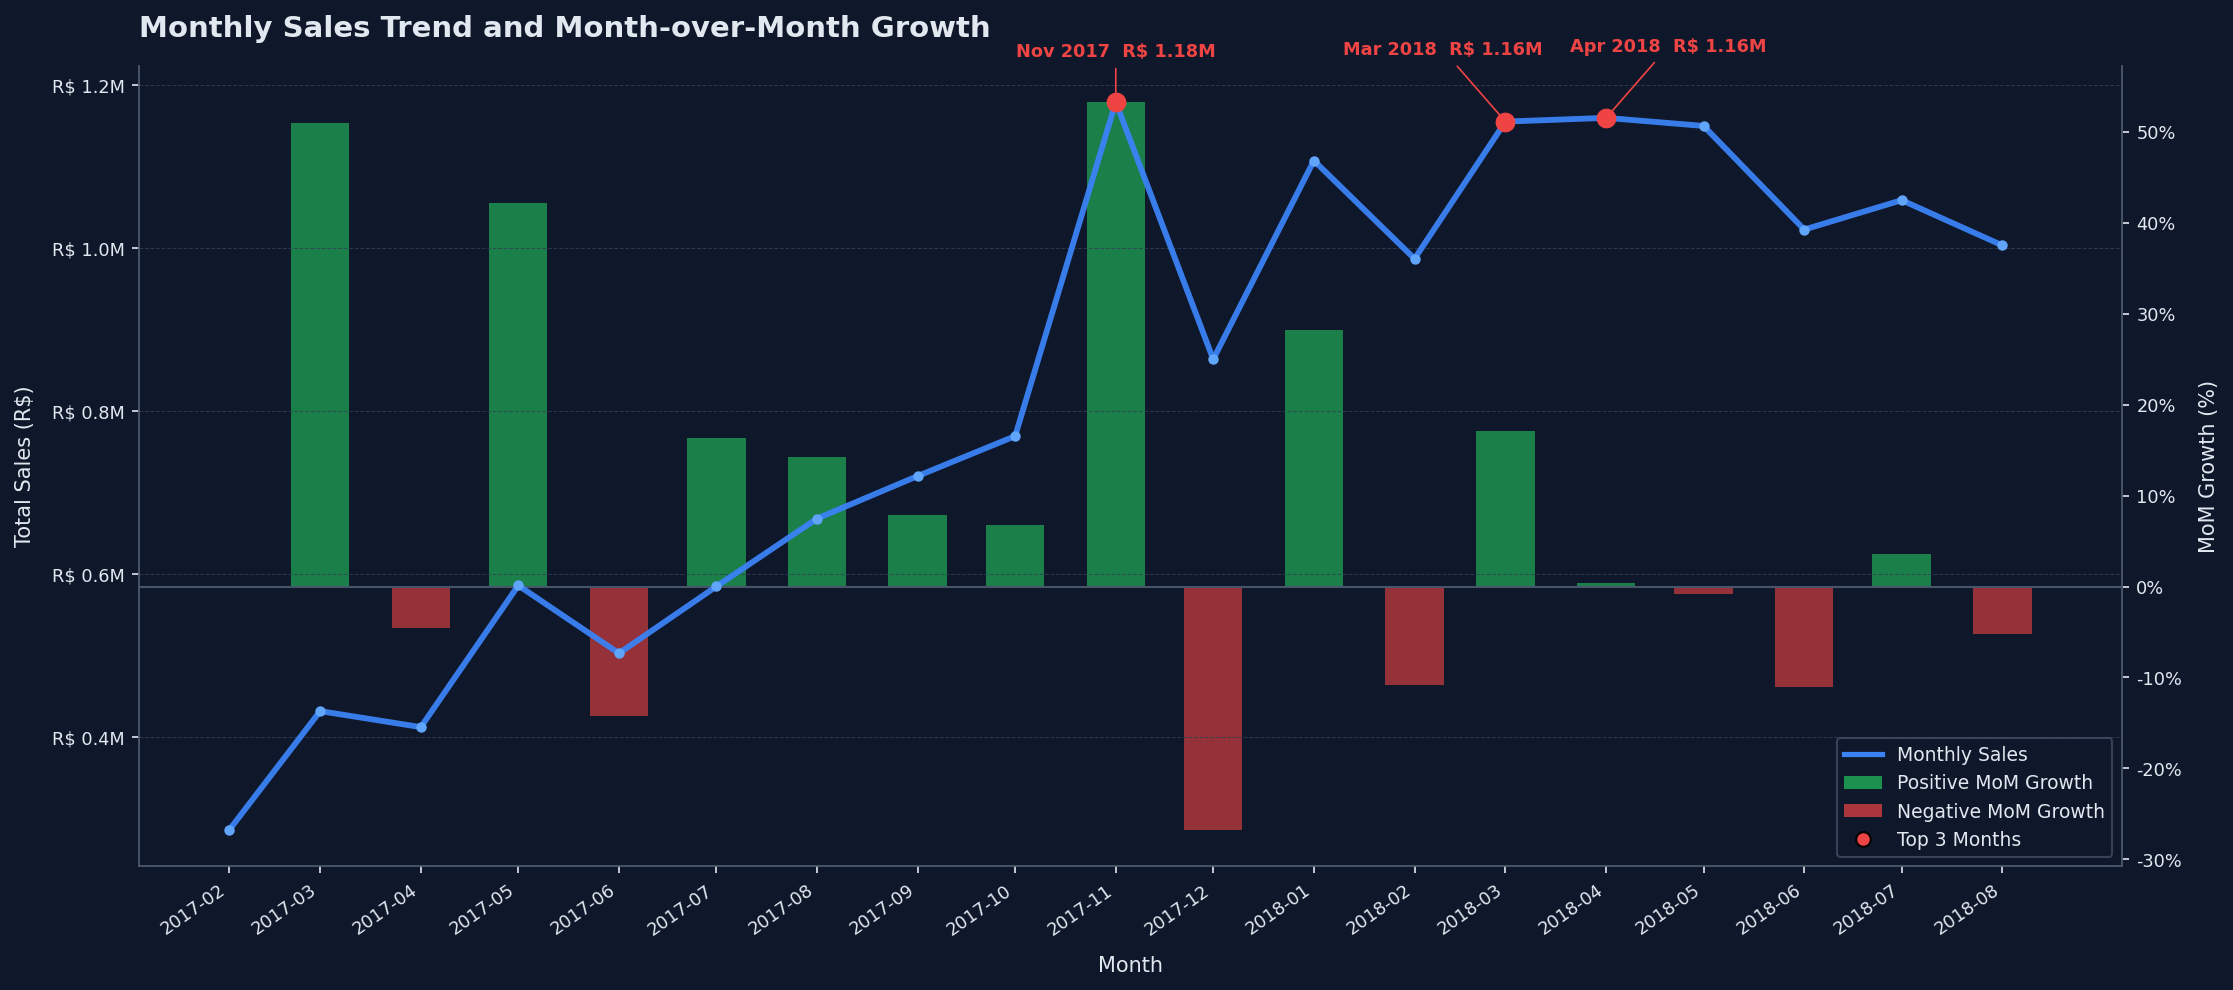

In [1]:
from IPython.display import Image, display
display(Image('outputs/question_2/sales_trend.png', width=800))

**Key finding:** Sales show strong overall growth from early 2017 through mid-2018 with clear seasonal spikes.
MoM growth is volatile in early months and stabilises as the platform matures.
The top three months by revenue represent a disproportionate share of total annual sales.

**Recommendation:** Build seasonal inventory and staffing plans around identified peak months.
Monitor MoM trend as a leading indicator of platform health.
Flat or declining MoM months warrant investigation into demand-side or marketing factors.

---
## Question 3 — Seller Revenue Outlook (Bootstrap Simulation)

**Business question:** What can a new seller realistically expect to earn in a typical month, and how uncertain is that outcome?

---

**Method**

| Step | Detail |
|---|---|
| Empirical distribution | One revenue observation per `(seller_id, month)` pair — no parametric shape assumed |
| Bootstrap simulation | 10,000 draws **with replacement** from the empirical population |
| Each draw | Represents one hypothetical seller-month; 10,000 draws give a stable simulated distribution |
| Reproducibility | `np.random.default_rng(seed=42)` — identical draws every run |
| Chart display | Clipped at 99th percentile so extreme outliers don't compress the visible distribution |

---

**What is bootstrap sampling?**

Each of the 10,000 draws is a random sample with replacement from the observed seller-month revenue records — one draw, one hypothetical seller outcome. Rather than fitting a parametric distribution (normal, lognormal), the method uses the empirical data itself as the population, so the simulated distribution inherits the actual shape of seller revenue: the right skew, the long tail, and the concentration of low earners.

**Bootstrap simulation core — from `src/question3.py`:**

In [ ]:
import numpy as np

# revenue_values: 1-D NumPy array of historical seller-month revenues
rng = np.random.default_rng(seed=42)          # reproducible modern Generator API
simulated = rng.choice(revenue_values, size=10_000, replace=True)

# Summary statistics
stats = {
    "mean":         np.mean(simulated),
    "median":       np.median(simulated),
    "ci_low":       np.percentile(simulated, 2.5),
    "ci_high":      np.percentile(simulated, 97.5),
    "p_below_500":  (simulated < 500).mean() * 100,
    "p_below_1000": (simulated < 1000).mean() * 100,
    "p_above_5000": (simulated > 5000).mean() * 100,
}

print(f'Median:    R$ {stats["median"]:>8,.0f}')
print(f'Mean:      R$ {stats["mean"]:>8,.0f}  ← pulled up by high-earners')
print(f'95%% CI:   R$ {stats["ci_low"]:,.0f} – R$ {stats["ci_high"]:,.0f}')
print(f'P(< R$500): {stats["p_below_500"]:.1f}%')
print(f'P(>R$5000): {stats["p_above_5000"]:.1f}%')

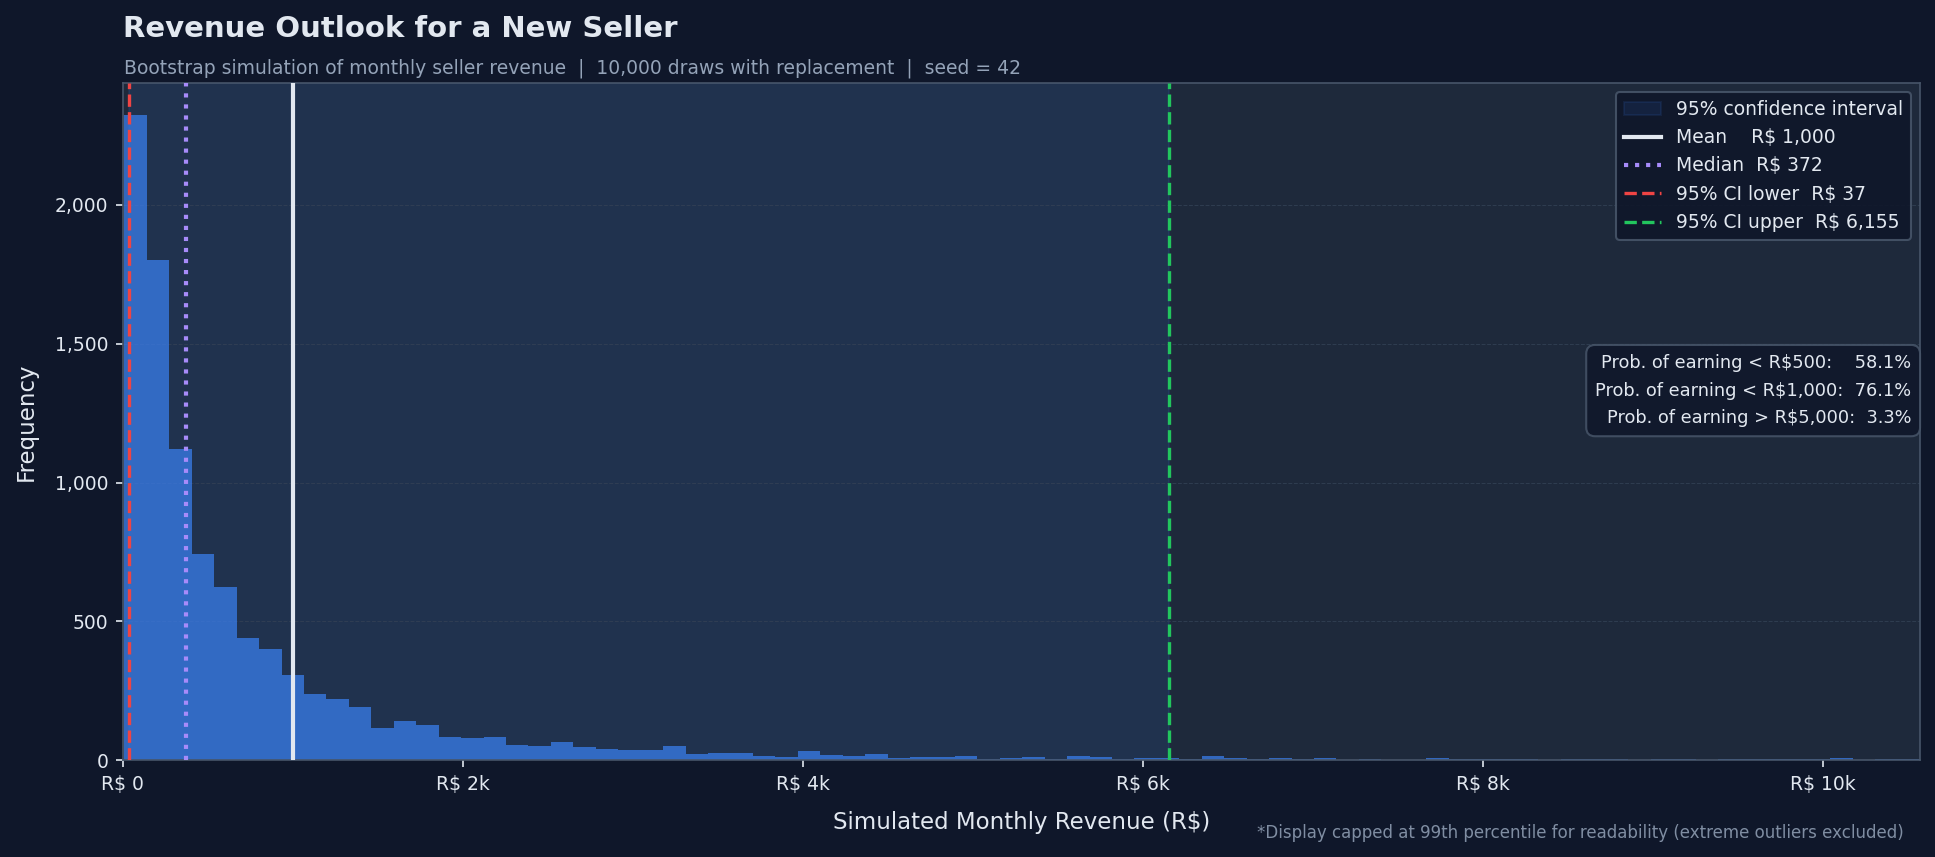

In [1]:
from IPython.display import Image, display
display(Image('outputs/question_3/bootstrap_sim.png', width=800))

In [1]:
# Simulation output — key probability metrics from the 10,000-draw bootstrap
# Results are deterministic: seed=42 is fixed in src/question3.py
from src.question3 import load_seller_monthly_revenue, run_simulation, compute_stats
import pandas as pd
revenue_values = load_seller_monthly_revenue()
simulated = run_simulation(revenue_values)
s = compute_stats(simulated)
rows = [
    ('Median monthly revenue',        'R$ {:,.0f}'.format(s['median'])),
    ('Mean monthly revenue',           'R$ {:,.0f}  (pulled up by top earners)'.format(s['mean'])),
    ('95% CI lower bound',             'R$ {:,.0f}'.format(s['ci_low'])),
    ('95% CI upper bound',             'R$ {:,.0f}'.format(s['ci_high'])),
    ('P(earn below R$500)',            '{:.1f}%'.format(s['p_below_500'])),
    ('P(earn below R$1,000)',          '{:.1f}%'.format(s['p_below_1000'])),
    ('P(earn above R$5,000)',          '{:.1f}%'.format(s['p_above_5000'])),
]
pd.DataFrame(rows, columns=['Metric', 'Value'])

#,Metric,Value
1,Median monthly revenue,R$ 372
2,Mean monthly revenue,"R$ 1,000 (pulled up by top earners)"
3,95% CI lower bound,R$ 37
4,95% CI upper bound,"R$ 6,155"
5,P(earn below R$500),58.1%
6,"P(earn below R$1,000)",76.1%
7,"P(earn above R$5,000)",3.3%


**Reading the table above:**

The median (R\$372) is the honest benchmark for a new seller — it is what a typical seller earns in a month.

The mean (R\$1,000) is nearly 3× higher, pulled up by a small number of high-performing months in the tail of the distribution.

The 95% CI spans BRL 37 to BRL 6,155 — a 166× range. That width is not a modelling artefact; it reflects genuine market variability. More than half of all seller-months fall below BRL 500.

**Business recommendation**

Quote **median revenue (BRL 372)** and concrete probability thresholds — 58.1% of months earn below BRL 500, 76.1% below BRL 1,000, only 3.3% above BRL 5,000 — in seller onboarding materials rather than the mean. Presenting the mean (BRL 1,000) sets an expectation fewer than 1 in 4 sellers will meet.

Consider targeted support programmes for sellers in the bottom revenue quartile, where month-to-month earnings are most volatile and most likely to fall below a viable operating threshold.

---
## Question 4 — Payment Methods: Risk vs Value

**Business question:** Do payment methods differ in cancellation risk and average order value,
and what trade-offs exist between reliability and revenue?

**Method:**
- Orders with multiple payment types excluded — only single-type orders used for clean, unambiguous attribution
- Cancellation defined as `order_status = 'canceled'` only
- Orders with `order_status = 'unavailable'` are excluded from the cancellation metric — they likely reflect fulfillment or inventory issues rather than payment-related behavior, so including them would distort the comparison across payment methods
- Metrics per payment type: order count, cancellation rate, average order value (AOV), total revenue
- **Risk–value bubble chart:** X = AOV, Y = cancellation rate, bubble size = order volume, colour = total revenue (viridis)
- Quadrant lines drawn at cross-method mean AOV and mean cancellation rate

**Quadrant interpretation:**

| Quadrant | Meaning |
|---|---|
| Low Risk / High Value | Ideal — reliable and high-spending |
| High Risk / High Value | Revenue at risk — worth targeted intervention |
| Low Risk / Low Value | Safe but limited upside |
| High Risk / Low Value | Problematic — high friction, low return |

**Key finding:** A clear risk–value trade-off exists across payment methods.
Some methods carry higher cancellation rates while also generating higher average order values.
Debit card and voucher behaviour differs markedly from credit card.

**Recommendation:** Segment cancellation-reduction strategies by payment method.
Consider targeted incentives — loyalty points, instalment offers — for methods with
strong AOV but elevated cancellation rates.

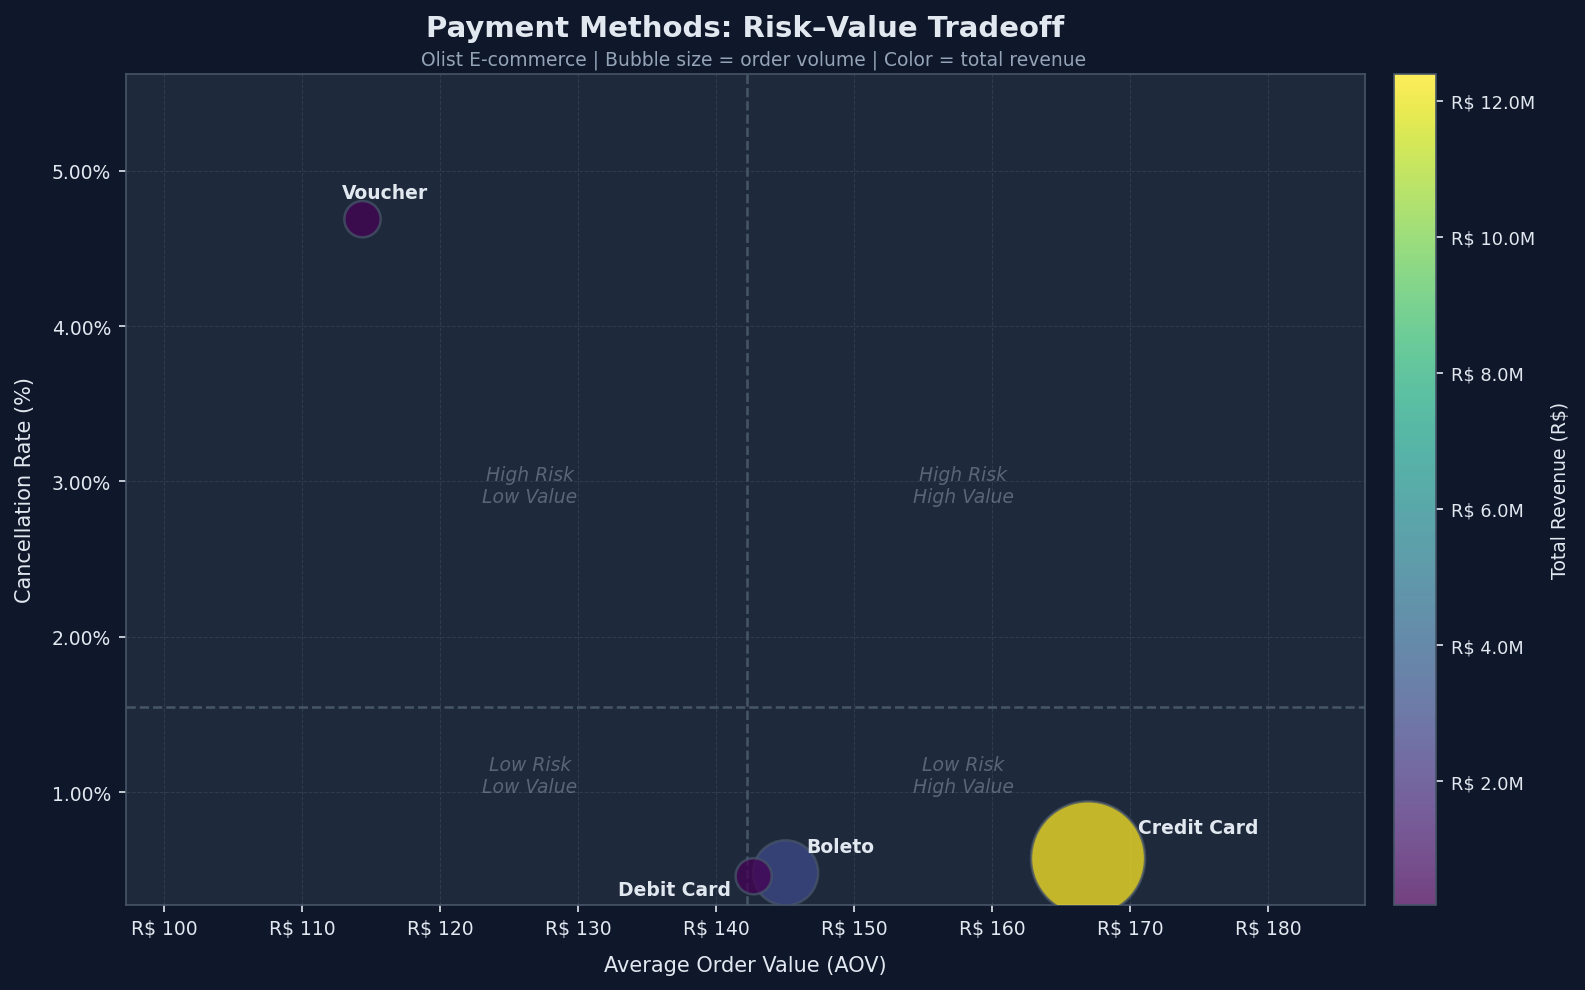

In [1]:
from IPython.display import Image, display
display(Image('outputs/question_4/risk_matrix.png', width=800))

---
## Overall Takeaways

| Question | Core Finding | Business Action |
|---|---|---|
| Logistics | Geography explains lead time partially — residuals expose carrier and infrastructure gaps | Audit high-residual, high-volume states |
| Sales | Strong growth with seasonal concentration; top 3 months drive disproportionate revenue | Plan capacity around peak months |
| Revenue | Seller earnings are right-skewed; the median is the honest benchmark, not the mean | Use median + CI in onboarding, not averages |
| Payments | Clear risk–value trade-off by payment method | Segment retention strategy by payment type |


---
## How to Run Locally

```bash
# 1. Clone the repository
git clone https://github.com/avi2898/Brazilian-eCommerce-Data-Project.git
cd Brazilian-eCommerce-Data-Project

# 2. Install dependencies
pip install -r requirements.txt

# 3. Download the Olist dataset from Kaggle
#    https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
#    Place all 9 CSV files in the data/ folder

# 4. Build the SQLite database (one-time — takes ~30 seconds)
python -m src.db_setup

# 5. Run the full analysis suite
python main.py

# Or run a single question
python main.py --question 1   # Logistics efficiency
python main.py --question 2   # Sales trends
python main.py --question 3   # Bootstrap simulation
python main.py --question 4   # Payment methods
```

Charts are saved to `outputs/question_N/` and shown interactively.  
For a deeper technical walkthrough see [`docs/codebase_guide.md`](docs/codebase_guide.md).